# Kernel PCA, Graph Kernels and Eigenmaps

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/kernellib/blob/main/docs/notebooks/graph_embeddings.ipynb)

Kernels also give low-dimensional pictures of data. This notebook walks through kernellib's decomposition tools: kernel PCA, which is PCA in a kernel's feature space; neighbourhood graphs and the graph kernels built on them; and the graph embeddings — Laplacian eigenmaps, their steerable generalisation Schrödinger eigenmaps, and locality preserving projections.

**What you'll learn:**

1. Why kernel PCA separates structure that linear PCA cannot, and how to scale it with a feature map.
2. Building a neighbourhood graph (exact in JAX, or approximately with pynndescent) and turning it into a Laplacian.
3. Unrolling a manifold with Laplacian eigenmaps.
4. Steering an embedding with Schrödinger eigenmaps: partial labels and barrier potentials.
5. Using a graph diffusion kernel for semi-supervised classification.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "kernellib[neighbors] @ git+https://github.com/jejjohnson/kernellib@main",
        ],
        check=True,
    )

In [2]:
import time
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import kernellib as kl


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p jax,matplotlib,kernellib")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.17.1

jax       : 0.11.2
matplotlib: 3.11.2
kernellib : 0.0.7

Compiler    : Clang 20.1.4 
OS          : Linux
Release     : 6.18.44-fc-v37
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## Kernel PCA

Two concentric circles are not linearly separable, and linear PCA only rotates them. Kernel PCA with an RBF kernel works with the centred Gram matrix $\tilde K = HKH$ instead of the covariance: its top eigenvectors $u_j$ give the components $z_j = \sqrt{\lambda_j}\, u_j$ on the training points, and a new point is projected with its (centred) kernel row. The radial structure becomes a direction.

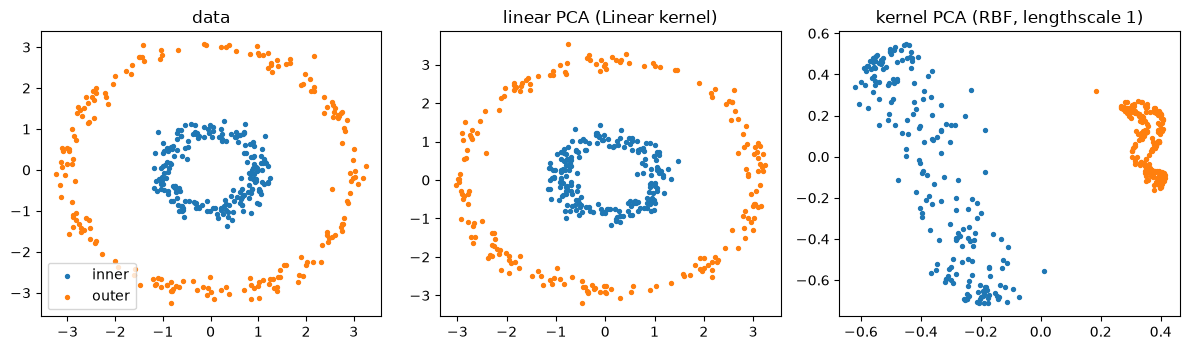

In [4]:
rng = np.random.default_rng(0)
n = 400
radius = np.where(np.arange(n) < n // 2, 1.0, 3.0)
angle = rng.uniform(0, 2 * np.pi, n)
circles = np.stack([radius * np.cos(angle), radius * np.sin(angle)], axis=1)
circles = jnp.asarray(circles + 0.15 * rng.normal(size=(n, 2)))
ring = radius > 2

pca = kl.KernelPCA(kl.Linear(), n_components=2).fit(circles)
kpca = kl.KernelPCA(kl.RBF(lengthscale=1.0), n_components=2).fit(circles)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, Z, title in [
    (axes[0], circles, "data"),
    (axes[1], pca.embedding, "linear PCA (Linear kernel)"),
    (axes[2], kpca.embedding, "kernel PCA (RBF, lengthscale 1)"),
]:
    ax.scatter(Z[~ring, 0], Z[~ring, 1], s=8, label="inner")
    ax.scatter(Z[ring, 0], Z[ring, 1], s=8, label="outer")
    ax.set_title(title)
axes[0].legend()
plt.tight_layout()
plt.show()

With a `Linear` kernel, kernel PCA *is* PCA (the test suite checks this against an SVD). With the RBF kernel the first component separates the two rings.

The exact path costs $O(N^3)$. Passing a feature map as `approx` turns kernel PCA into ordinary PCA of $\phi(X)$ in $O(N R^2)$; with 300 random Fourier features the components agree closely with the exact ones:

In [5]:
approx = kl.KernelPCA(
    kl.RBF(lengthscale=1.0),
    n_components=2,
    approx=kl.RandomFourierFeatures(300, jax.random.key(0)),
).fit(circles)
exact_first = kpca.embedding[:, 0]
approx_first = approx.embedding[:, 0]
corr = jnp.abs(jnp.corrcoef(exact_first, approx_first)[0, 1])
print(f"|correlation| of the first component, exact vs 300 RFF: {corr:.3f}")

|correlation| of the first component, exact vs 300 RFF: 0.987


## Neighbourhood graphs

The graph methods start from a k-nearest-neighbour graph. `kl.nearest_neighbors` is an exact, batched brute-force search in JAX, $O(N^2 D)$ time and $O(BN)$ memory for a row block of $B$. For large $N$, `backend="pynndescent"` uses approximate NN-descent (`pip install "kernellib[neighbors]"`); `backend="sklearn"` uses scikit-learn's trees. Both are imported only when chosen.

Here is the classic Swiss roll: a 2-D sheet rolled up in 3-D. Its intrinsic coordinate is the roll parameter $t$.

In [6]:
def swiss_roll(n, seed=0):
    rng = np.random.default_rng(seed)
    t = 1.5 * np.pi * (1 + 2 * rng.uniform(size=n))
    h = 21 * rng.uniform(size=n)
    X = np.stack([t * np.cos(t), h, t * np.sin(t)], axis=1)
    return jnp.asarray(X), t


X_roll, t_roll = swiss_roll(1500)

start = time.perf_counter()
exact = kl.nearest_neighbors(X_roll, 10)
exact.indices.block_until_ready()
t_exact = time.perf_counter() - start

start = time.perf_counter()
approx_graph = kl.nearest_neighbors(X_roll, 10, backend="pynndescent", random_state=0)
t_nnd = time.perf_counter() - start

agree = np.mean(
    [
        len(set(a) & set(b)) / 10
        for a, b in zip(
            np.asarray(exact.indices), np.asarray(approx_graph.indices), strict=True
        )
    ]
)
print(f"exact: {t_exact:.2f} s   pynndescent: {t_nnd:.2f} s (includes numba JIT)")
print(f"pynndescent recall of the exact 10-NN: {agree:.3f}")

exact: 0.35 s   pynndescent: 20.84 s (includes numba JIT)
pynndescent recall of the exact 10-NN: 1.000


At this size the exact search is fast; NN-descent pays off at hundreds of thousands of points, where the $N^2$ distance computation is the bottleneck. Its first call here also includes numba's compilation.

`kl.adjacency_matrix` weights the edges with the heat kernel $w_{ij} = \exp(-d_{ij}^2 / 2\sigma^2)$ ($\sigma$ defaults to the median neighbour distance) and symmetrises the graph; `kl.graph_laplacian` gives $L = D - W$.

## Laplacian eigenmaps

Laplacian eigenmaps (Belkin & Niyogi, 2003) choose coordinates $y_i$ that keep neighbours close,

$$\min_Y \sum_{ij} W_{ij} \|y_i - y_j\|^2 = 2\, \mathrm{tr}(Y^\top L Y) \quad \text{s.t.} \quad Y^\top D Y = I,$$

whose solutions are the smallest non-trivial eigenvectors of $L y = \lambda D y$. Because only neighbourhood distances matter, the embedding follows the sheet, not the ambient space: it unrolls the roll.

rank correlation of the first coordinate with t: -1.000
dense vs ARPACK eigenvalues: [0.000473 0.002027] [0.000473 0.002027]


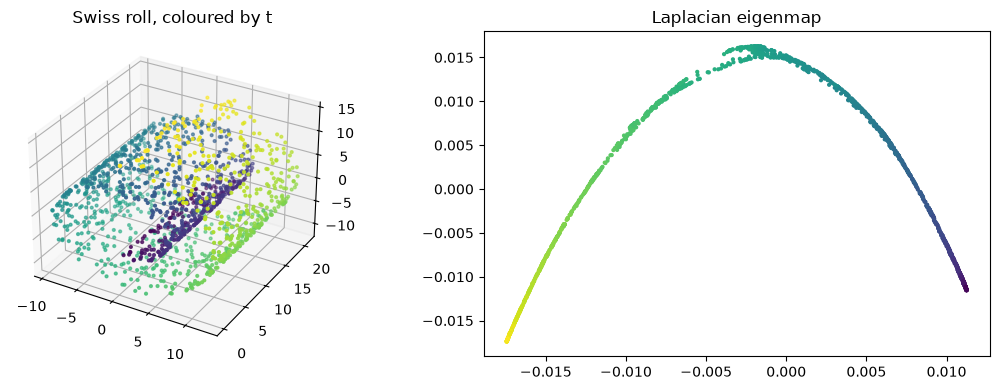

In [7]:
le = kl.LaplacianEigenmaps(n_components=2, n_neighbors=10).fit(X_roll)
le_sparse = kl.LaplacianEigenmaps(
    n_components=2, n_neighbors=10, eigen_solver="arpack"
).fit(X_roll)


def rank_corr(a, b):
    ra, rb = np.argsort(np.argsort(a)), np.argsort(np.argsort(b))
    return np.corrcoef(ra, rb)[0, 1]


rho = rank_corr(le.embedding[:, 0], t_roll)
print(f"rank correlation of the first coordinate with t: {rho:+.3f}")
print(
    "dense vs ARPACK eigenvalues:",
    np.round(np.asarray(le.eigenvalues), 6),
    np.round(np.asarray(le_sparse.eigenvalues), 6),
)

fig = plt.figure(figsize=(11, 4))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2], c=t_roll, s=4, cmap="viridis")
ax.set_title("Swiss roll, coloured by t")
ax = fig.add_subplot(1, 2, 2)
ax.scatter(le.embedding[:, 0], le.embedding[:, 1], c=t_roll, s=4, cmap="viridis")
ax.set_title("Laplacian eigenmap")
plt.tight_layout()
plt.show()

The colour (the roll parameter) varies smoothly along the first coordinate. The dense solver runs in JAX and is differentiable in the edge weights; `eigen_solver="arpack"` keeps the graph sparse and gives the same eigenvalues, for graphs too big for an $N \times N$ matrix.

## Schrödinger eigenmaps

Schrödinger eigenmaps (Czaja & Ehler, 2013) add a potential $V \succeq 0$ to the Laplacian,

$$(L + \alpha V)\, y = \lambda D y,$$

which adds $\alpha\, \mathrm{tr}(Y^\top V Y)$ to the objective. The potential is how prior knowledge enters an otherwise unsupervised embedding:

- `kl.label_potential(labels)` is the Laplacian of the graph joining labelled points that share a label, so it adds $\alpha \sum_{i \sim j} \|y_i - y_j\|^2$: **partial labels pull their classes together** (semi-supervised).
- `kl.barrier_potential(n, idx)` is diagonal, adding $\alpha \sum_{i \in \text{idx}} \|y_i\|^2$: it **pins chosen points** near the origin.
- `kl.spatial_spectral_potential(X, coordinates)` joins spatial neighbours (e.g. adjacent pixels) weighted by spectral similarity, the non-diagonal potential used for hyperspectral images (Cahill, Czaja & Messinger, 2014).

With `normalize_potential=True` (the default) $\alpha$ is scaled by $\mathrm{tr}(L)/\mathrm{tr}(V)$, so it is a relative weight that does not depend on the size of the data. At $\alpha = 0$ it is exactly Laplacian eigenmaps.

Below, three classes are defined by position along the roll, and only 5% of the points are labelled.

71 labelled points out of 1500


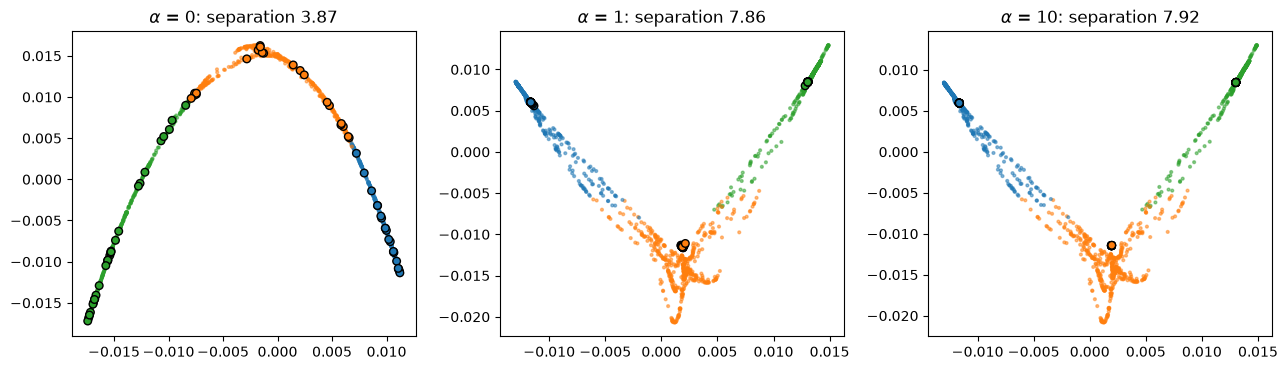

In [8]:
classes = np.digitize(t_roll, np.quantile(t_roll, [1 / 3, 2 / 3]))
labelled = np.random.default_rng(1).uniform(size=len(t_roll)) < 0.05
labels = jnp.asarray(np.where(labelled, classes, -1))
print(f"{int(labelled.sum())} labelled points out of {len(t_roll)}")

alphas = [0.0, 1.0, 10.0]
embeddings = {}
for a in alphas:
    se = kl.SchrodingerEigenmaps(n_components=2, n_neighbors=10, alpha=a)
    embeddings[a] = se.fit(X_roll, kl.label_potential(labels)).embedding


def class_separation(Y):
    # Mean distance between class centroids over mean within-class spread.
    cents = np.stack([np.asarray(Y)[classes == c].mean(0) for c in range(3)])
    within = np.mean(
        [
            np.linalg.norm(np.asarray(Y)[classes == c] - cents[c], axis=1).mean()
            for c in range(3)
        ]
    )
    between = np.mean(
        [np.linalg.norm(cents[i] - cents[j]) for i in range(3) for j in range(i + 1, 3)]
    )
    return between / within


fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, a in zip(axes, alphas, strict=True):
    Y = embeddings[a]
    ax.scatter(Y[:, 0], Y[:, 1], c=classes, s=4, cmap="tab10", vmax=9, alpha=0.5)
    ax.scatter(
        Y[labelled, 0],
        Y[labelled, 1],
        c=classes[labelled],
        s=30,
        cmap="tab10",
        vmax=9,
        edgecolors="k",
    )
    ax.set_title(rf"$\alpha$ = {a:g}: separation {class_separation(Y):.2f}")
plt.tight_layout()
plt.show()

Circled points are the labelled ones; colours are the true classes. As $\alpha$ grows, the label potential pulls each class together: the between-class to within-class ratio roughly doubles by $\alpha = 1$ and then saturates, even though 95% of the points carry no label. The graph propagates the pull from the labelled points to their neighbours.

A barrier potential does something different: it pins the chosen points to the origin, and the embedding reorganises around them.

In [9]:
anchors = jnp.flatnonzero(jnp.asarray(t_roll < np.quantile(t_roll, 0.05)))
V_barrier = kl.barrier_potential(len(t_roll), anchors)
se_barrier = kl.SchrodingerEigenmaps(
    n_components=2, n_neighbors=10, alpha=10.0, drop_first=False
).fit(X_roll, V_barrier)
Yb = se_barrier.embedding
dist_to_origin = np.linalg.norm(np.asarray(Yb), axis=1)
pinned = dist_to_origin[np.asarray(anchors)].mean()
free = np.delete(dist_to_origin, np.asarray(anchors)).mean()
print(f"mean |y| of the {len(anchors)} pinned points: {pinned:.2e}")
print(f"mean |y| of the other points: {free:.2e}")

mean |y| of the 75 pinned points: 4.88e-07
mean |y| of the other points: 1.42e-02


## Locality preserving projections

The eigenmaps embed only the points they were fitted on. Locality preserving projections (He & Niyogi, 2003) restrict the embedding to be linear, $y = A^\top (x - \mu)$, solving $X^\top L X a = \lambda X^\top D X a$, so new points can be projected with `transform`. The graph, not the variance, chooses the directions. We fit on 1,200 points and project the 300 held-out ones, measuring how many of each test point's 10 nearest neighbours survive the projection:

In [10]:
X_train, X_test = X_roll[:1200], X_roll[1200:]
lpp = kl.LocalityPreservingProjections(n_components=2, n_neighbors=10).fit(X_train)
pca_roll = kl.KernelPCA(kl.Linear(), n_components=2).fit(X_train)


def neighbour_overlap(A, B, k=10):
    a = np.asarray(kl.nearest_neighbors(A, k).indices)
    b = np.asarray(kl.nearest_neighbors(B, k).indices)
    return np.mean([len(set(x) & set(y)) / k for x, y in zip(a, b, strict=True)])


kept_lpp = neighbour_overlap(X_test, lpp.transform(X_test))
kept_pca = neighbour_overlap(X_test, pca_roll.transform(X_test))
print(f"test-set 10-NN kept by LPP: {kept_lpp:.3f}")
print(f"test-set 10-NN kept by PCA: {kept_pca:.3f}")

test-set 10-NN kept by LPP: 0.395
test-set 10-NN kept by PCA: 0.454


No linear map can unroll the sheet, so neither keeps most neighbourhoods, and on this data LPP does no better than PCA. What LPP adds over the eigenmaps is out-of-sample projection; when the neighbourhood structure matters more than the variance, as in the 5-D plane test in `tests/decomposition/test_eigenmaps.py`, its graph-chosen directions keep far more neighbours than an arbitrary projection.

## Graph kernels: semi-supervised classification

A graph kernel is a spectral function of the Laplacian, $K = U f(\Lambda) U^\top$, and is positive semidefinite. The diffusion kernel $K = e^{-\beta L}$ measures how much heat placed on one node reaches another in time $\beta$ (Kondor & Lafferty, 2002). Summing each class's column of $K$ over the labelled points gives a simple semi-supervised classifier: every point takes the class whose labelled points "heat" it most. Similarity flows along the graph, so the roll's layers, close in space but far along the sheet, do not leak into each other.

In [11]:
n_small = 600
X_small, t_small = X_roll[:n_small], t_roll[:n_small]
classes_small = classes[:n_small]
labelled_small = labelled[:n_small]

W_small = kl.adjacency_matrix(kl.nearest_neighbors(X_small, 10))
K_diff = kl.diffusion_kernel(W_small, beta=20.0)
K_rbf = kl.RBF(lengthscale=kl.estimate_lengthscale(X_small))(X_small, X_small)


def classify(K):
    scores = np.stack(
        [
            np.asarray(K)[:, labelled_small & (classes_small == c)].sum(1)
            for c in range(3)
        ],
        axis=1,
    )
    pred = scores.argmax(1)
    return np.mean(pred[~labelled_small] == classes_small[~labelled_small])


print(f"{int(labelled_small.sum())} labelled points")
acc_diff, acc_rbf = classify(K_diff), classify(K_rbf)
print(f"accuracy on unlabelled points, diffusion kernel on the graph: {acc_diff:.3f}")
print(f"accuracy on unlabelled points, RBF kernel in 3-D:            {acc_rbf:.3f}")

26 labelled points
accuracy on unlabelled points, diffusion kernel on the graph: 0.920
accuracy on unlabelled points, RBF kernel in 3-D:            0.730


The RBF kernel measures distance through the ambient space, so points on adjacent layers of the roll look alike; the diffusion kernel measures it along the manifold.

## Summary

- `kl.KernelPCA` is PCA in feature space; `approx=` makes it $O(NR^2)$.
- `kl.nearest_neighbors` builds k-NN graphs exactly in JAX or approximately with pynndescent; `kl.adjacency_matrix` and `kl.graph_laplacian` turn them into weights and Laplacians.
- `kl.LaplacianEigenmaps` unrolls manifolds; `kl.SchrodingerEigenmaps` steers the embedding with label, barrier or spatial potentials; `kl.LocalityPreservingProjections` is the linear version with out-of-sample projection.
- Graph kernels (`diffusion_kernel`, `regularized_laplacian_kernel`, ...) are PSD similarities that follow the graph.
- All of these have scikit-learn adapters in `kernellib.sklearn`.